This notebook constructs the ML$^{WC}$ model for the water slab - Ne system with applied field (corresponding to Figure 1 in the manuscript).

The external field and wannierization calculations are performed on 20 selected frames from the water_Ne trajectory. The step indices are defined by `step_index_list`. Static calculation jobs are named as `pure_water_20frame_{STEP}`. Wannierization calculation jobs are names as `step{STEP}_Necharge0d1_wannier`.

The first two sections shows how to construct the wannier dipole array and ACE descriptor matrix by reading the raw DFT data using pyiron. These matrices are included in the dataset as `.npy` files. One can also directly start with the third section `read matrix and construct ML model` which reads the `.npy` files and constructs the model. In this case, the pyiron and pyace packages are not needed. 

In [3]:
from pyiron import Project
import numpy as np
%matplotlib inline
import matplotlib.pylab as plt
import pyace

In [4]:
plt.rcParams.update(
    {'font.size': 24, 'legend.fontsize': 20, 
     'legend.handlelength': 0.5, 'lines.markersize':10,
     'axes.linewidth':2})

In [5]:
pr = Project('water_Ne')


Mg - 8, O - 6, H - 1, Ne - (8 - 2/24)
H126MgNe24O63
total number of electrons: 702

In [6]:
job = pr.load('pure_water_20frame_0')
struct = job.get_structure()

2026-03-06 10:23:08,554 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2026-03-06 10:23:08,569 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2026-03-02/lib/python3.12/site-packages/pyiron_snippets/resources.py:295: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_gamma_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2026-03-02/lib/python3.12/site-packages/pyiron_snippets/resources.py:295: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2026-03-02/lib/python3.12/site-packages/pyiron_snippets/resources.py:295

In [284]:
index_Ne = struct.select_index('Ne')

In [76]:
step_index_list = np.arange(0, 1200, 60)

# get wannier dipole

In [5]:
from pyiron import ase_to_pyiron
from ase import Atoms

In [5]:
def wrap_positions(cell, positions):
    """
    Wraps multiple positions into the periodic cell.

    Parameters:
        cell (numpy.ndarray): 3x3 matrix defining the periodic cell.
        positions (numpy.ndarray): Nx3 matrix where each row is a 3D vector [x, y, z].

    Returns:
        numpy.ndarray: Nx3 matrix of wrapped positions inside the periodic cell.
    """
    # Inverse of the cell matrix
    cell_inv = np.linalg.inv(cell)

    # Convert positions to fractional coordinates (transpose positions for dot product)
    fractional = np.dot(positions, cell_inv.T)

    # Wrap fractional coordinates into [0, 1)
    fractional_wrapped = fractional - np.floor(fractional)

    # Convert wrapped fractional coordinates back to Cartesian coordinates
    wrapped_positions = np.dot(fractional_wrapped, cell.T)

    return wrapped_positions


In [6]:
def get_wannier_charge(file, struct, roll_grid_z = 200):
    Lx = struct.cell[0][0]
    Ly = struct.cell[1][1]
    Lz = struct.cell[2][2]
    index_H = struct.select_index('H')
    index_O = struct.select_index('O')
    index_Ne = struct.select_index('Ne')
    #index_Mg = struct.select_index('Mg')
    wc = np.loadtxt(file, skiprows=2, dtype ='str')
    wc_line = [index  for index, row in enumerate(wc) if row[0] == "X"]
    wc_pos = np.array(wc[wc_line, 1:4], dtype = 'float')
    wc_pos_wrap = wrap_positions(struct.cell, wc_pos)
    wc_pos_wrap[wc_pos_wrap[:, 2] > 40, 2] -= Lz
    return wc_pos_wrap

In [7]:
def get_water_molecule_wannier(job):
    struct = job.get_structure(-1)
    wc_struct = struct.copy()
    file = job.working_directory+ '/wannier90_centres.xyz'
    wc_pos_wrap = get_wannier_charge(file, struct)   
    for i in range(len(wc_pos_wrap)):
        wc_center = Atoms(symbols = ['N'], positions = [wc_pos_wrap[i]], cell = struct.cell.copy(),pbc=True)
        wc_center = ase_to_pyiron(wc_center)
        wc_struct += wc_center
    index_N = wc_struct.select_index('N')
    index_H = wc_struct.select_index('H')
    index_O = wc_struct.select_index('O')
    nn = wc_struct.get_neighbors(8)
    positions = wc_struct.positions
    positions_wrap = wrap_positions(wc_struct.cell, positions)
    water_pos_list = []
    water_dipole_list = []
    dipole_index_list = []
    for iO in index_O:
        nn_wc = 0
        nn_H = 0
        dipole = 0
        nn_H_list = []
        nn_wc_list = []
        vec_OH = np.zeros((2, 3))
        vec_Ow = np.zeros((4, 3))
        for i in range(8):
            if nn.indices[iO][i] in index_N:
                nn_wc_list.append(nn.indices[iO][i])
                vec_Ow[nn_wc] = nn.vecs[iO][i]
                nn_wc += 1
            if nn_wc == 4:
                break
        for i in range(8):
            if nn.indices[iO][i] in index_H:
                nn_H_list.append(nn.indices[iO][i])
                vec_OH[nn_H] = nn.vecs[iO][i]
                nn_H += 1
            if nn_H == 2:
                break  
        assert nn_H == 2
        assert nn_wc == 4
        dipole = np.sum(vec_OH, axis = 0)*-1 + \
                np.sum(vec_Ow, axis = 0)*2
        pos_wc_ave = np.mean(positions_wrap[nn_wc_list], axis = 0)
        water_pos_list.append([positions_wrap[iO], positions_wrap[nn_H_list[0]], positions_wrap[nn_H_list[1]], pos_wc_ave])
        water_dipole_list.append(dipole)  
        dipole_index_list.append(np.array([iO, nn_H_list[0], nn_H_list[1], nn_wc_list[0], nn_wc_list[1], nn_wc_list[2], nn_wc_list[3]]))
    return water_pos_list, water_dipole_list, dipole_index_list

In [8]:
step_index_list = np.arange(0, 1200, 60)
Ne_charge = 0.1
dipole_list_0d1 = []
for step_index in step_index_list:
    job = pr.load('step'+str(step_index)+'_Necharge'+str(Ne_charge)+'_wannier')
    water_pos_list, water_dipole_list, dipole_index_list = get_water_molecule_wannier(job)
    dipole_list_0d1.append(water_dipole_list)

2025-10-27 14:23:16,753 - pyiron_log - DEBUG - sql_query: {'job': 'step0_Necharge0d1_wannier', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-10-27 14:23:16,767 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-10-21/lib/python3.12/site-packages/pyiron_snippets/resources.py:295: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_gamma_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-10-21/lib/python3.12/site-packages/pyiron_snippets/resources.py:295: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-10-21/lib/python3.12/site-packages/pyiron_snippets/resources.p

NameError: name 'Atoms' is not defined

In [11]:
wannier_dipole_list = np.array(dipole_list_0d1).reshape([-1, 3])

In [42]:
phi_20frame = np.load('phi_20frame_Ne_0d1.npy')

In [13]:
dipole_frame_z_wannier = wannier_dipole_list[:, 2].reshape(-1, 64).sum(axis = 1)

In [21]:
np.save('wannier_dipole_20frame_pure_water_Ne0d1.npy', wannier_dipole_list)

# train ace potential

In [15]:
# H Mg Ne O
def make_ace(**kwargs):
    calc = pyace.PyACECalculator(
            './Mg_200.yaml'
    )
    return calc

In [16]:
def get_descr(ace, structure):
    #del structure.calc
    structure.calc = ace
    structure.get_potential_energy()
    return np.array(structure.calc.ace.projections)

In [17]:
ace = make_ace()

In [114]:
cos_test_list = []
descriptor_list = []
core_center_list = []
core_center_list_x = []
core_center_list_y = []
z_list = []
vec_list = []
for step_index in step_index_list:
    job = pr.load('pure_water_20frame_'+str(step_index))
    struct = job.get_structure(-1)
    #d_ace = get_descr(ace, struct)
    nn = struct.get_neighbors(num_neighbors= 2)
    index_O = struct.select_index('O')
    for iO in index_O:
        #ddd = np.insert(d_ace[iO], 0, 1) 
        vec1 = nn.vecs[iO][0]
        vec2 = nn.vecs[iO][1]
        i_H1 = nn.indices[iO][0]
        i_H2 = nn.indices[iO][1]
        #ddd_H1 = np.insert(d_ace[i_H1], 0, 1) 
        #ddd_H2 = np.insert(d_ace[i_H2], 0, 1) 
        z_norm = np.array([0, 0, 1])
        vec = (vec1 + vec2)/2
        cos_theta = np.dot(vec, z_norm)/np.linalg.norm(vec)
        cos_test_list.append(cos_theta)
        #descriptor_list.append(np.concatenate((ddd, ddd_H1, ddd_H2)))
        core_center = (struct.positions[iO, 2]*6 + struct.positions[i_H1,2] + struct.positions[i_H2, 2])/8
        core_center_list.append(core_center)
        core_center = (struct.positions[iO, 0]*6 + struct.positions[i_H1,0] + struct.positions[i_H2, 0])/8
        core_center_list_x.append(core_center)
        core_center = (struct.positions[iO, 1]*6 + struct.positions[i_H1,1] + struct.positions[i_H2, 1])/8
        core_center_list_y.append(core_center)
        z_list.append([struct.positions[iO, 2], struct.positions[i_H1,2], struct.positions[i_H2,2]])
        vec_list.append([vec1, vec2])
cos_test_list = np.array(cos_test_list)
descriptor_list = np.array(descriptor_list)
vec_list  = np.array(vec_list)

2025-12-04 13:37:38,700 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-12-04 13:37:38,885 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-04 13:37:38,885 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-04 13:37:38,904 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-04 13:37:38,904 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-04 13:37:38,906 - pyiron_log - DEBUG - Not supported parameter used!
2025-12-04 13:37:38,919 - pyiron_log - DEBUG - Not supported parameter used!
2025-12-04 13:37:39,104 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_60', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-12-04 13:37:39,302 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-04 13:37:39,302 - pyiron_log - WARNING - Could not access indices, returning None!
2025-12-04 13:37:39

In [115]:
np.save('core_center_individual_list_x.npy', core_center_list_x)
np.save('core_center_individual_list_y.npy', core_center_list_y)

In [25]:
np.save('cos_individual_list.npy', cos_test_list)
np.save('descriptor_individual_charge_onlyO_list.npy', descriptor_list)
np.save('core_center_individual_list.npy', core_center_list)
np.save('z_individual_charge_list.npy', z_list)

In [26]:
vec_3d_list = []
vec_OH1_list = []
vec_OH2_list = []
vec_norm_list = []
for i in range(len(vec_list)):
    c = np.cross(vec_list[i,0], vec_list[i, 1])
    c = c/np.linalg.norm(c)
    b1 = vec_list[i,0]/np.linalg.norm(vec_list[i,0])
    b2 = vec_list[i,1]/np.linalg.norm(vec_list[i,1])
    vec_3d_list.append([b1, b2, c])
    vec_OH1_list.append(b1)
    vec_OH2_list.append(b2)
    vec_norm_list.append(c)
vec_3d_list = np.array(vec_3d_list)
vec_OH1_list = np.array(vec_OH1_list)
vec_OH2_list = np.array(vec_OH2_list)
vec_norm_list = np.array(vec_norm_list)

In [28]:
np.save('vec_3d_list_tenframe.npy', vec_3d_list)

In [29]:
core_dipole_list = []
for step_index in step_index_list:
    job = pr.load('pure_water_20frame_'+str(step_index))
    struct = job.get_structure(-1)
    core_dipole = get_core_dipole(struct)
    core_dipole_list.append(core_dipole)
core_dipole_list = np.array(core_dipole_list)
np.save('core_dipole_individual_list.npy', core_dipole_list)

2025-06-23 07:46:27,287 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-06-23 07:46:27,478 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:27,478 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:27,496 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:27,496 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:27,498 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-23 07:46:27,508 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_60', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-06-23 07:46:27,713 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:27,713 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:27,729 - pyiron_log - WARNING - Could not access indices, returning None!
2025-

In [30]:
core_dipole_OH_list = []
for step_index in step_index_list:
    job = pr.load('pure_water_20frame_'+str(step_index))
    struct = job.get_structure(-1)
    core_dipole = get_core_dipole(struct, element_list = ['O', 'H'], q_list = [6, 1])
    core_dipole_OH_list.append(core_dipole)
core_dipole_OH_list = np.array(core_dipole_OH_list)
np.save('core_dipole_OH_individual_list.npy', core_dipole_OH_list)

2025-06-23 07:46:35,531 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-06-23 07:46:35,717 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:35,717 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:35,735 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:35,735 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:35,736 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-23 07:46:35,747 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_60', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-06-23 07:46:35,951 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:35,951 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-23 07:46:35,966 - pyiron_log - WARNING - Could not access indices, returning None!
2025-

In [291]:
def decompose_vector(a, b1, b2):
    """
    Decomposes a vector 'a' into components along 'b1', 'b2' (plane basis) and 'c' (normal).
    
    Parameters:
    a  : (3,) array-like, the vector to be decomposed
    b1 : (3,) array-like, first basis vector of the plane
    b2 : (3,) array-like, second basis vector of the plane
    c  : (3,) array-like, normal vector to the plane

    Returns:
    (x, y, z): Coefficients such that a = x * b1 + y * b2 + z * c
    """
    c = np.cross(b1, b2)
    c = c/np.linalg.norm(c)

    b1_norm = b1/np.linalg.norm(b1)
    b2_norm = b2/np.linalg.norm(b2)
    # Construct the basis matrix B with b1, b2, and normal c as columns
    B = np.column_stack((b1_norm, b2_norm, c))  # Shape (3,3)

    # Solve for x, y, z
    xyz = np.linalg.solve(B, a)  # Solves B * [x, y, z] = a
    
    return xyz

In [32]:
xyz_list = []
for i in range(1280):   
    xyz = decompose_vector(wannier_dipole_list[i], vec_OH1_list[i, :], vec_OH2_list[i, :])
    xyz_list.append(xyz)

In [33]:
np.save('xyz_individual_list.npy', xyz_list)

# read matrix and construct ML model

In [9]:
core_dipole_OH_list = np.load('core_dipole_OH_individual_list.npy')
cos_list = np.load('cos_individual_list.npy')
coeff_matrix_list_train = np.load('descriptor_individual_charge_onlyO_list.npy')

In [10]:
xyz_list = np.load('xyz_individual_list.npy')

In [11]:
z_list = np.load('z_individual_charge_list.npy')

In [12]:
core_center_list = np.load('core_center_individual_list.npy')

In [13]:
core_center_list_x = np.load('core_center_individual_list_x.npy')
core_center_list_y = np.load('core_center_individual_list_y.npy')

In [14]:
phi_train = np.load('phi_20frame_Ne_0d1.npy')

In [15]:
vec_3d_list = np.load('vec_3d_list_tenframe.npy')

In [16]:
wannier_dipole_list = np.load('wannier_dipole_20frame_pure_water_Ne0d1.npy')

In [17]:
n_element = 1

In [18]:
pos_Ne = 24.656269320469203

In [21]:
mat = np.array(coeff_matrix_list_train) #* np.array(cos_list)

m, n = mat.shape  # Get matrix dimensions
I = np.eye(n)   # Identity matrix of size n x n
lambda_reg = 0.01
# Compute regularized solution: x = (A^T A + lambda*I)^-1 A^T b
mat_inv = np.linalg.inv(mat.T @ mat + lambda_reg * I) @ mat.T
d_matrix_x = mat_inv @ xyz_list[:, 0]
d_matrix_y = mat_inv @ xyz_list[:, 1]
d_matrix_z = mat_inv @ xyz_list[:, 2]

In [22]:
mat = np.array(coeff_matrix_list_train)
np.shape(mat)

(1280, 603)

In [84]:
np.save('d_matrix_x_nfunc100.npy', d_matrix_x)
np.save('d_matrix_y_nfunc100.npy', d_matrix_y)
np.save('d_matrix_z_nfunc100.npy', d_matrix_z)

In [23]:
x_predict =  mat @ d_matrix_x 
y_predict =  mat @ d_matrix_y
z_predict =  mat @ d_matrix_z 


In [24]:

xyz_predict = np.array([x_predict, y_predict, z_predict]).T

In [25]:
dipole_predict = np.einsum('ij,ijk->ik', xyz_predict, vec_3d_list) 

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_25311/4166995117.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('DFT $\mu^{H_2O}_z\ (e\cdot \mathrm{\AA})$')
/tmp/ipykernel_25311/4166995117.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('ML $\mu^{H_2O}_z\ (e\cdot \mathrm{\AA})$')


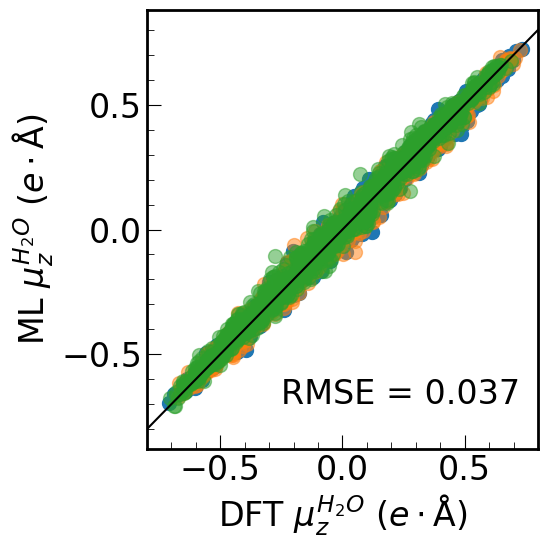

In [26]:
fig, ax = plt.subplots(figsize = (6,6))

plt.scatter(wannier_dipole_list[:, 0], dipole_predict[:, 0], label = 'x')
plt.scatter(wannier_dipole_list[:, 1], dipole_predict[:, 1], label = 'y', alpha  = 0.5)
plt.scatter(wannier_dipole_list[:, 2], dipole_predict[:, 2], label = 'z', alpha  = 0.5)

plt.plot([-0.8, 0.8], [-0.8, 0.8], color = 'Black')
plt.xlabel('DFT $\mu^{H_2O}_z\ (e\cdot \mathrm{\AA})$')
plt.ylabel('ML $\mu^{H_2O}_z\ (e\cdot \mathrm{\AA})$')
#plt.legend(frameon = False)
plt.xlim(-0.8, 0.8)
ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()

plt.tight_layout()
plt.text(-0.25, -0.7, 'RMSE = 0.037')

plt.savefig('learn_individual_dipole_correlation_field.png', dpi = 300)

# dipole prediction on the xy direction

In [27]:
dipole_frame_z = dipole_predict[:, 2].reshape(-1, 64).sum(axis = 1)
dipole_frame_z_wannier = wannier_dipole_list[:, 2].reshape(-1, 64).sum(axis = 1)

In [28]:
slope, intercept = np.polyfit(dipole_frame_z_wannier, dipole_frame_z, 1)

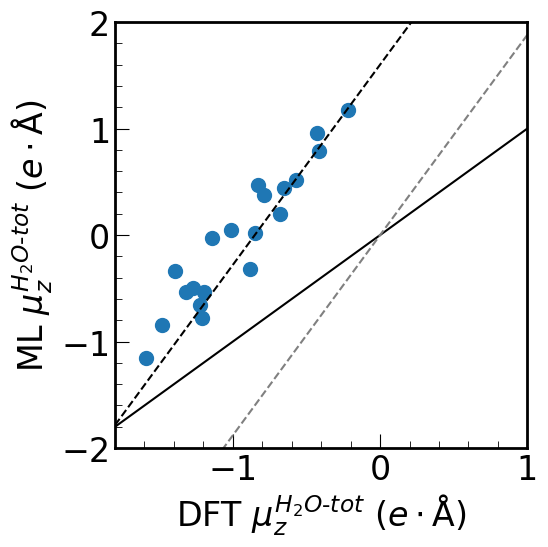

In [29]:
fig, ax = plt.subplots(figsize = (6,6))

plt.scatter(dipole_frame_z_wannier, dipole_frame_z )
plt.plot([-1.8, 1], [-1.8, 1], color = 'Black')
plt.plot([-1.8, 1], np.array([-1.8*1.88, 1*1.88])+1.6, '--', color = 'Black')
plt.plot([-1.8, 1], np.array([-1.8*1.88, 1*1.88]), '--', color = 'Grey')


ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()


plt.xlim(-1.8, 1)
plt.ylim(-2, 2)
plt.xlabel(r'DFT $\mu_z^{H_2O\text{-}tot}\ (e\cdot\mathrm{\AA})$')
plt.ylabel(r'ML $\mu_z^{H_2O\text{-}tot}\ (e\cdot\mathrm{\AA})$')

plt.tight_layout()
plt.savefig('learn_individual_dipole_correlation_global_field.png', dpi = 300)

## xy direction

In [30]:
dipole_frame_x = dipole_predict[:, 0].reshape(-1, 64).sum(axis = 1)
dipole_frame_x_wannier = wannier_dipole_list[:, 0].reshape(-1, 64).sum(axis = 1)

In [31]:
dipole_frame_y = dipole_predict[:, 1].reshape(-1, 64).sum(axis = 1)
dipole_frame_y_wannier = wannier_dipole_list[:, 1].reshape(-1, 64).sum(axis = 1)

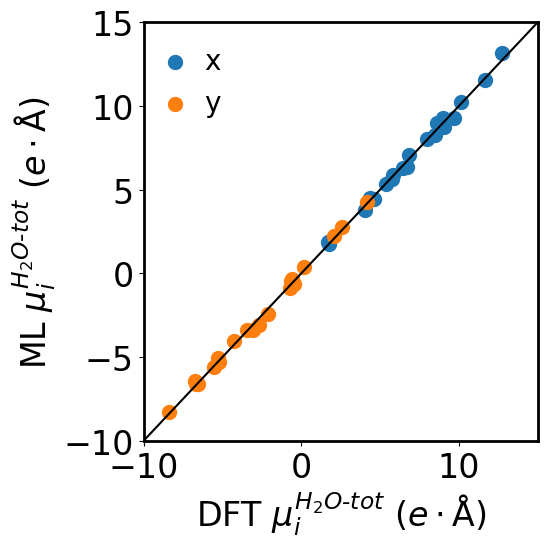

In [32]:
fig, ax = plt.subplots(figsize = (6,6))



plt.scatter(dipole_frame_x_wannier, dipole_frame_x, label = 'x' )
plt.scatter(dipole_frame_y_wannier, dipole_frame_y, label = 'y' )
plt.plot([-10, 15], [-10, 15], color = 'Black')
plt.xlim(-10, 15)
plt.ylim(-10, 15)
plt.legend(frameon = False)

plt.xlabel(r'DFT $\mu_i^{H_2O\text{-}tot}\ (e\cdot\mathrm{\AA})$')
plt.ylabel(r'ML $\mu_i^{H_2O\text{-}tot}\ (e\cdot\mathrm{\AA})$')

plt.tight_layout()
plt.savefig('learn_individual_dipole_correlation_global_field_xy.png', dpi = 300)

In [62]:
descriptor_list_verify = np.load('descriptor_list_verify.npy')

In [72]:
np.shape(descriptor_list_verify)

(76800, 603)

In [63]:
mat_verify = descriptor_list_verify

In [64]:
x_verify =  mat_verify @ d_matrix_x 
y_verify =  mat_verify @ d_matrix_y
z_verify =  mat_verify @ d_matrix_z 

In [65]:
xyz_verify = np.array([x_verify, y_verify, z_verify]).T

In [66]:
vec_3d_list_verify = np.load('vec_3d_list_verify.npy')

In [67]:
dipole_predict_verify = np.einsum('ij,ijk->ik', xyz_verify, vec_3d_list_verify) 

In [68]:
dipole_frame_z_verify = dipole_predict_verify[:, 2].reshape(-1, 64).sum(axis = 1)


In [69]:
phi_1200frame = np.load('phi_train_verify.npy')

In [85]:
slope, _ = np.polyfit(phi_1200frame, dipole_frame_z_verify, 1)

In [86]:
slope

1.8943267290319254

# reconstruct el pot from WC

In [38]:
Ne_charge = 0.1
i_plot = 0
step_index = step_index_list[i_plot]


In [32]:
struct = job.get_structure(-1)
Lz = struct.cell[2][2]
z_grid = np.linspace(0, Lz, 648, endpoint = False)

2025-10-27 14:25:53,730 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 14:25:53,730 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 14:25:53,751 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 14:25:53,751 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 14:25:53,754 - pyiron_log - DEBUG - Not supported parameter used!


In [34]:
dipole_predict_z_step = dipole_predict[:, 2].reshape([-1, 64])

In [36]:
def calc_el_pot_1d(charge_density, Lz, epsilon_0=0.005526349358057108):
    n_grid = len(charge_density)
    z = np.linspace(0, Lz, n_grid, endpoint=False)
    dz = z[1] - z[0]
    # Fourier transform of charge density
    rho_k = np.fft.fft(charge_density)

    # Define wave numbers (k-space grid)
    k = 2 * np.pi * np.fft.fftfreq(n_grid, d=dz)

    # Solve Poisson’s equation in Fourier space: ϕ_k = -ρ_k / (ε₀ k²)
    phi_k = np.zeros_like(rho_k, dtype=np.complex128)
    
    # Avoid division by zero at k=0 (mean charge mode)
    mask = k != 0
    phi_k[mask] = -rho_k[mask] / (epsilon_0 * k[mask]**2)

    # Transform back to real space
    phi = np.real(np.fft.ifft(phi_k))

    return phi    

In [37]:
def calc_dipole_1d(chargedensity, Lz, nz, gridposition=550, grid_roll = 100):
    chargedensity_roll = chargedensity.copy()
    chargedensity_roll = np.roll(chargedensity_roll, grid_roll)
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint = False)
    dipole = np.sum(chargedensity_roll*z) * dz
    if(np.abs(dipole)<1e-5): return 0, chargedensity
    dx_dipolcorr = 8 # in gridpoints
    q = dipole / (dx_dipolcorr*dz)
    new_chargedensity = chargedensity.copy()
    new_chargedensity[gridposition] = q / dz
    new_chargedensity[gridposition+dx_dipolcorr] = -q / dz
    return dipole, new_chargedensity

In [38]:
def get_gaussian_charge_shift(dipole_predict, Ne_charge, core_center_list, O_pos_list, H_pos_list, z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, total_dipole, Lz, nz = 648, dipole_mul = 1, shift = False):
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint=False)
    rho  = np.zeros_like(z)
    n_roll = 90
    z_roll = n_roll*dz
    # water 
    for i in range(64):
        # el
        r_dipole = dipole_mul * dipole_predict[i] / 8
        pos_z = core_center_list[i] + r_dipole
        if shift == True:
            pos_z += alpha_water * total_dipole
        q = 8
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_water_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_water_el)**2)
        rho += gaussian
    # water core
    for i in range(64):
        pos_z = O_pos_list[i]
        q = -6
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_O)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_O)**2)
        rho += gaussian
    for i in range(128):
        pos_z = H_pos_list[i]
        q = -1
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_H)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_H)**2)
        rho += gaussian

    # charge of Ne
    # core
    q = -(8-Ne_charge/12)
    pos_z = z_Ne
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian
    #el
    q = 8
    pos_z = z_Ne
    if shift == True:
        pos_z += alpha_Ne * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    q = -(8+Ne_charge/12)
    pos_z = 0
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian

    q = 8
    pos_z = 0
    if shift == True:
        pos_z += alpha_Ne * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    rho = np.roll(rho, -n_roll)
    return z, rho

In [39]:
core_center_list_frame = core_center_list.reshape([-1, 64])

In [59]:
Lx = 8.464068
Ly = 8.464068
Lz = 44.055096

z_Ne = 24.656269320469203

sigma_Ne = 1.3/4
sigma_Ne_el = 0.45 #0.462

sigma_water = 0.30857
sigma_O = 0.34 #sigma_water
sigma_H =  0.2 #sigma_water
sigma_water_el = 0.5263 #0.5111

i_plot = 16 # 18
step_index = step_index_list[i_plot]

Ne_charge = 0.1

job = pr.load('step'+str(step_index)+'_Necharge'+str(Ne_charge))
el_pot_dft = job.get_electrostatic_potential().get_average_along_axis(2)
struct = job.get_structure(-1)

index_O = struct.select_index('O')
O_pos = struct.positions[index_O, 2]

index_H = struct.select_index('H')
H_pos = struct.positions[index_H, 2]

alpha_Ne = 1/(64*8+24*8+6)
alpha_water = 1/(64*8+24*8+6)

 
z, rho = get_gaussian_charge_shift(dipole_predict_z_step[i_plot], Ne_charge, core_center_list_frame[i_plot], O_pos, H_pos,  z_Ne, sigma_Ne, sigma_O, sigma_H,  sigma_Ne_el, sigma_water_el,  alpha_Ne, alpha_water, 0, Lz, nz = 648, dipole_mul = 1, shift = False)
dipole_shift, rho_corr = calc_dipole_1d(rho, Lz, 648, gridposition=502, grid_roll = 100)  
phi = calc_el_pot_1d(-rho_corr/Lx/Ly, Lz)    


2025-10-27 15:02:28,140 - pyiron_log - DEBUG - sql_query: {'job': 'step960_Necharge0d1', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-10-27 15:02:28,152 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2025-10-27 15:02:28,478 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 15:02:28,478 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 15:02:28,499 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 15:02:28,499 - pyiron_log - WARNING - Could not access indices, returning None!
2025-10-27 15:02:28,501 - pyiron_log - DEBUG - Not supported parameter used!


In [43]:
alpha_water = 0
alpha_Ne = 1/(12*8)

sigma_water = 0.30857
sigma_O = 0.34 #sigma_water
sigma_H =  0.2 #sigma_water
sigma_water_el = 0.5263 #0.5111


wannier_dipole_frame_z = wannier_dipole_list[:, 2].reshape(-1, 64)
dipole_shift = phi_20frame[i_plot]-(dipole_frame_z_wannier[i_plot] + pos_Ne*0.1)
z, rho_wan = get_gaussian_charge_shift(wannier_dipole_frame_z [i_plot], Ne_charge, core_center_list_frame[i_plot], O_pos, H_pos,  z_Ne, sigma_Ne, sigma_O, sigma_H,  sigma_Ne_el, sigma_water_el,  alpha_Ne, alpha_water, dipole_shift, Lz, nz = 648, dipole_mul = 1, shift = True)
dipole_wan, rho_wan = calc_dipole_1d(rho_wan, Lz, 648, gridposition=502, grid_roll = 100)  
phi_wan = calc_el_pot_1d(-rho_wan/Lx/Ly, Lz)  

In [60]:
job_0 = pr.load('pure_water_20frame_corr_'+str(step_index))
el_pot_0 = job_0.get_electrostatic_potential().get_average_along_axis(2)


2025-10-27 15:02:32,454 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_corr_960', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}


In [61]:
el_pot_0[502:540] = el_pot_0[532:570]
el_pot_0[532:560] = el_pot_0[600]

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_26224/1622814742.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(z, phi-phi[510], '--', color = 'Red', label = 'ML$^{\mathrm{WC}}$', linewidth = linewidth)
/tmp/ipykernel_26224/1622814742.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$z$ ($\mathrm{\AA}$)')
/tmp/ipykernel_26224/1622814742.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi$ (V)')


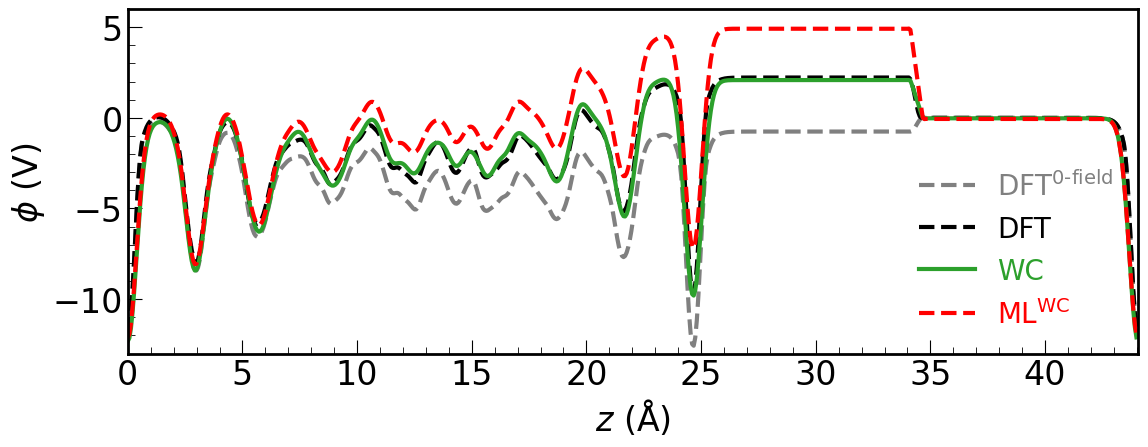

In [62]:
linewidth = 3
fig, ax = plt.subplots(figsize = (12,5))
plt.plot(z, el_pot_0-el_pot_0[510], '--', color = 'Grey', label = r'DFT$^{0\mathrm{\text{-}field}}$', linewidth = linewidth)
plt.plot(z, el_pot_dft - el_pot_dft[510], '--', color = 'Black', label = 'DFT', linewidth = linewidth)
plt.plot(z, phi_wan - phi_wan[510], '-', color = 'C2', label = 'WC', linewidth = linewidth)
plt.plot(z, phi-phi[510], '--', color = 'Red', label = 'ML$^{\mathrm{WC}}$', linewidth = linewidth)
#plt.axvline(z[532])
#plt.plot(z, el_pot_dft -phi, '--', color = 'Black')
plt.xlim(0, Lz)
legend = plt.legend(frameon = False, handlelength=2)

legend.get_texts()[0].set_color("Grey")
legend.get_texts()[1].set_color("Black")
legend.get_texts()[2].set_color("C2")
legend.get_texts()[3].set_color("Red")

plt.xlabel('$z$ ($\mathrm{\AA}$)')
plt.ylabel('$\phi$ (V)')

ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()

plt.tight_layout()
plt.ylim(-13, 6)
plt.savefig('el_pot_with_field.png', dpi = 300)

# function

In [14]:
def calc_el_pot_point_charge(z_list, charge_list, Lx, Ly, Lz, n_grid = 200, epsilon_0=0.005526349358057108):
    z = np.linspace(0, Lz, n_grid, endpoint=False)
    charge_density = np.zeros(n_grid)
    dz = z[1] - z[0]
    for i, z_pos in enumerate(z_list):
        index_z = int(np.floor(z_pos*n_grid/Lz)) 
        q = charge_list[i]
        if index_z == 0:
            charge_density[index_z] -= (q/dz/Lx/Ly)
            continue
        alpha_z = (z[index_z+1]-z_pos)/dz
        #print(alpha_z)
        charge_density[index_z] -= (q/dz/Lx/Ly)*alpha_z
        charge_density[index_z+1] -= (q/dz/Lx/Ly)*(1-alpha_z)
    # Fourier transform of charge density
    rho_k = np.fft.fft(charge_density)

    # Define wave numbers (k-space grid)
    k = 2 * np.pi * np.fft.fftfreq(n_grid, d=dz)

    # Solve Poisson’s equation in Fourier space: ϕ_k = -ρ_k / (ε₀ k²)
    phi_k = np.zeros_like(rho_k, dtype=np.complex128)
    
    # Avoid division by zero at k=0 (mean charge mode)
    mask = k != 0
    phi_k[mask] = -rho_k[mask] / (epsilon_0 * k[mask]**2)

    # Transform back to real space
    phi = np.real(np.fft.ifft(phi_k))

    return z, charge_density, phi    

In [15]:
def get_core_dipole(struct, element_list = [ 'O', 'H', 'Ne'], q_list = [6, 1, 8]):
    core_dipole = 0
    for i, el in enumerate(element_list):
        atom_index = struct.select_index(el)
        core_dipole += np.sum(q_list[i] * struct.positions[atom_index, 2])
    return core_dipole
        
    